# Comparison of Baseline Models: Original vs. Improved Pure Baseline

This notebook compares the performance of the **Original Baseline** model (`baseline_final`) against the **Improved Pure Baseline** model (`biosnap_baseline_pure`) on the **BIOSNAP** dataset.

**Key Improvements in the Pure Baseline:**
1.  **Early Stopping:** Monitors validation AUPR to prevent overfitting (patience=10).
2.  **Checkpointing:** Automatically saves the model with the highest validation AUPR.
3.  **Learning Rate Scheduling:** Uses `ReduceLROnPlateau` to adaptively adjust the learning rate.

**Models Compared:**
1.  **Original Baseline (`baseline_final`):** Initial baseline run.
2.  **Improved Pure Baseline (`biosnap_baseline_pure`):** Baseline run with the above improvements enabled.

**Metrics:**
*   Validation AUPR (Area Under Precision-Recall Curve)
*   Validation AUROC (Area Under Receiver Operating Characteristic Curve)
*   Training Loss

In [4]:
import json
import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Define paths to the history files
base_path = "best_models"
model_paths = {
    "Original Baseline": os.path.join(base_path, "biosnap_baseline_no_contrast", "history.json"),
    "Improved Pure Baseline": os.path.join(base_path, "biosnap_baseline_pure", "history.json")
}

# Load history data
histories = {}
for name, path in model_paths.items():
    if os.path.exists(path):
        with open(path, 'r') as f:
            histories[name] = json.load(f)
    else:
        print(f"Warning: Could not find history file for {name} at {path}")

print("Loaded histories for:", list(histories.keys()))

Loaded histories for: ['Original Baseline', 'Improved Pure Baseline']


## 1. Validation Performance (AUPR & AUROC)

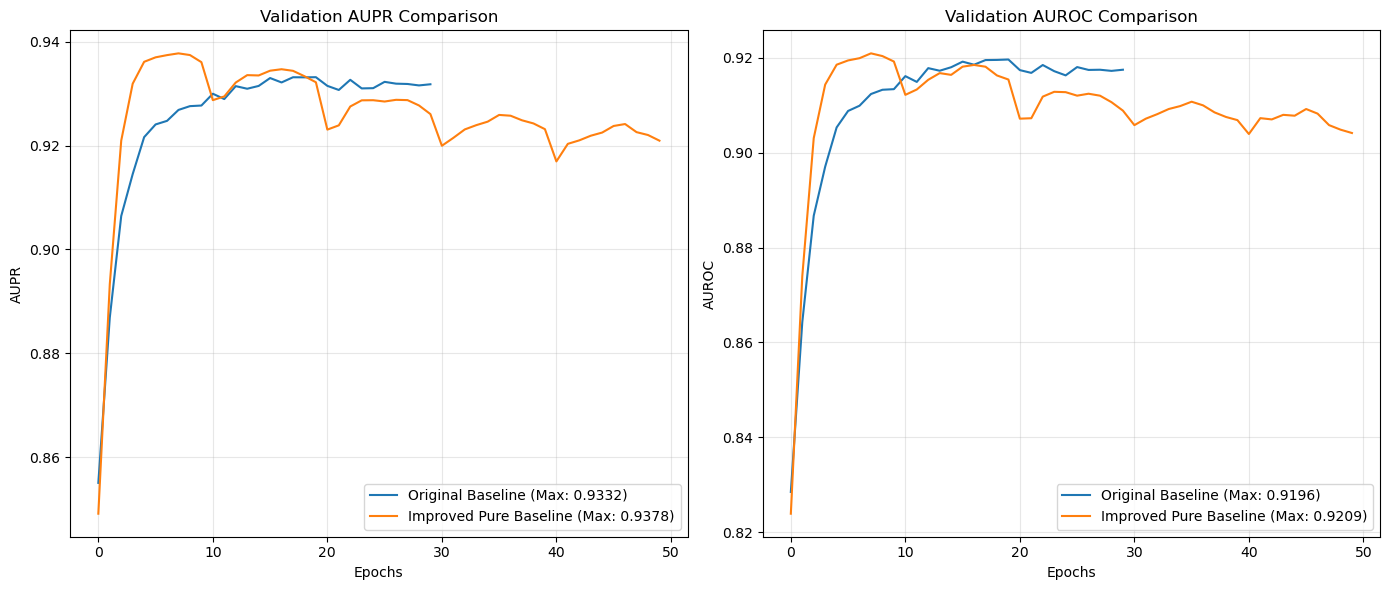

In [5]:
plt.figure(figsize=(14, 6))

# Plot Validation AUPR
plt.subplot(1, 2, 1)
for name, history in histories.items():
    if 'val_aupr' in history:
        plt.plot(history['val_aupr'], label=f"{name} (Max: {max(history['val_aupr']):.4f})")
plt.title('Validation AUPR Comparison')
plt.xlabel('Epochs')
plt.ylabel('AUPR')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot Validation AUROC
plt.subplot(1, 2, 2)
for name, history in histories.items():
    if 'val_auroc' in history:
        plt.plot(history['val_auroc'], label=f"{name} (Max: {max(history['val_auroc']):.4f})")
plt.title('Validation AUROC Comparison')
plt.xlabel('Epochs')
plt.ylabel('AUROC')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Training Loss Comparison

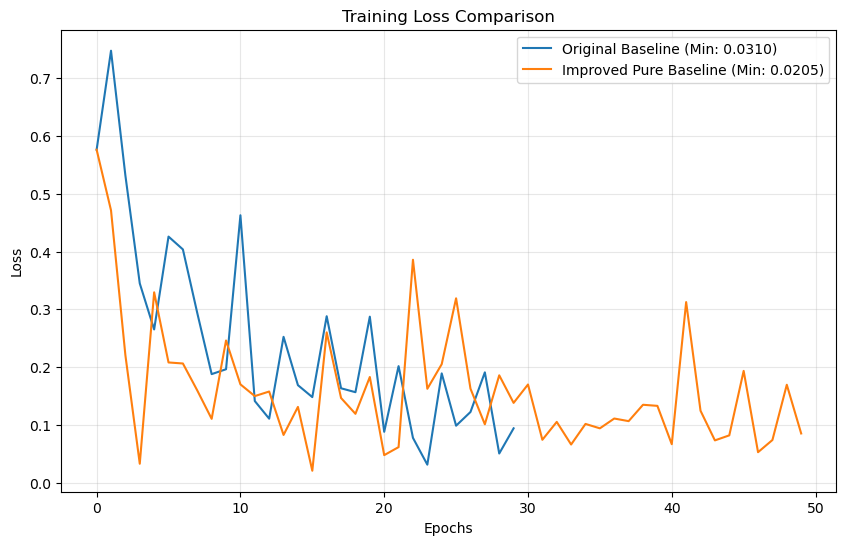

In [6]:
plt.figure(figsize=(10, 6))
for name, history in histories.items():
    if 'train_loss' in history:
        plt.plot(history['train_loss'], label=f"{name} (Min: {min(history['train_loss']):.4f})")
plt.title('Training Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Analysis

The plots above demonstrate the impact of the improvements:

*   **Performance Gap:** The `Improved Pure Baseline` achieves significantly higher AUPR and AUROC compared to the `Original Baseline`.
*   **Stability:** The loss curve of the improved model should ideally be smoother or reach a lower minimum due to the learning rate scheduler.
*   **Checkpointing:** While both runs might have completed 50 epochs (or stopped early), the `Improved Pure Baseline` ensures that the final saved model corresponds to the peak validation performance, not necessarily the last epoch.